# Análisis de Sentimiento con RNN y LSTM usando Word2Vec
## Dataset: IMDb 50K Movie Reviews

En esta actividad se replica el proceso de análisis de sentimiento trabajado anteriormente, utilizando el **mismo embedding Word2Vec Skip-gram** entrenado con el corpus IMDb. La diferencia fundamental es que ahora en lugar de usar Regresión Logística sobre vectores promedio, implementamos dos arquitecturas de redes neuronales secuenciales:

- **RNN simple (SimpleRNN)**: procesa la secuencia de tokens paso a paso, actualizando un estado oculto en cada paso.
- **LSTM (Long Short-Term Memory)**: una variante más sofisticada de RNN que incluye mecanismos de compuerta para controlar qué información recordar y qué olvidar.

El objetivo es comparar ambas arquitecturas entre sí y con el modelo anterior, analizando métricas, comportamiento de entrenamiento y decisiones de diseño.

### Integrantes: Yan Carlos Cuaran Imbacuan, Juan Manuel Velasquez Terreros

## 1. Instalación de dependencias

Se instalan las mismas dependencias del trabajo anterior más TensorFlow/Keras para las redes neuronales.

In [ ]:
!pip install kagglehub gensim tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.4 MB/s eta 0:00:00


## 2. Importaciones y configuración

Se importan todas las librerías necesarias para el procesamiento de texto, el embedding y la construcción de modelos.

In [ ]:
import pandas as pd
import numpy as np
import re
import kagglehub
from kagglehub import KaggleDatasetAdapter
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Semilla global
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Carga del dataset

Se carga el mismo dataset IMDb 50K Movie Reviews utilizado anteriormente. El dataset contiene 50.000 reseñas balanceadas (25.000 positivas, 25.000 negativas).

In [ ]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
    "IMDB Dataset.csv"
)

print(f"Forma del dataset: {df.shape}")
print(f"\nDistribución de clases:")
print(df['sentiment'].value_counts())
df.head(3)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Forma del dataset: (50000, 2)

Distribución de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 4. Limpieza del texto y tokenización

Se aplica exactamente el mismo proceso de limpieza y tokenización que en el trabajo anterior, para garantizar que el embedding se entrene con los mismos datos preprocesados. Esto es fundamental para poder comparar resultados de manera justa. Las reseñas de IMDb contienen ruido típico del formato web, como etiquetas HTML del tipo <-br /->, que no aportan ninguna información semántica y deben eliminarse. Luego se convierte todo a minúsculas para que palabras como Good y good sean tratadas como el mismo token, se eliminan los caracteres que no sean letras ni apóstrofes para conservar contracciones naturales del inglés como don't o it's, y finalmente se normalizan los espacios múltiples que quedan tras las sustituciones anteriores.

In [ ]:
# Limpieza del dataframe
df = df.dropna(subset=["review", "sentiment"]).drop_duplicates()
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})

def clean_text(text: str) -> str:
    """Limpia una reseña eliminando HTML, puntuación y normalizando mayúsculas."""
    text = re.sub(r"<br\s*/?>", " ", text)      # elimina saltos de línea HTML
    text = text.lower()                          # minúsculas
    text = re.sub(r"[^a-z\s']", " ", text)      # solo letras, espacios y apóstrofe
    text = re.sub(r"\s+", " ", text).strip()    # normaliza espacios
    return text

def tokenize(text: str):
    """Tokeniza por espacios (simple y efectivo tras la limpieza)."""
    return text.split()

df["clean_review"] = df["review"].astype(str).apply(clean_text)
df["tokens"] = df["clean_review"].apply(tokenize)

print(f"Total de reseñas después de limpieza: {len(df)}")
print(f"\nEjemplo de tokens (primeros 15):")
print(df["tokens"].iloc[0][:15])

Total de reseñas después de limpieza: 49582

Ejemplo de tokens (primeros 15):
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', "you'll", 'be']


## 5. Entrenamiento del embedding Word2Vec

Se entrena el mismo embedding Word2Vec Skip-gram utilizado en el trabajo anterior, con los mismos hiperparámetros: vectores de 100 dimensiones, ventana de contexto de 5 palabras, mínimo de 2 apariciones para incluir una palabra en el vocabulario, y arquitectura Skip-gram activada con sg=1. Reutilizamos este mismo embedding porque la idea es comparar el impacto de la arquitectura del clasificador, no del embedding.

La elección de Skip-gram sobre CBOW se justifica porque en el lenguaje de reseñas de cine las palabras más informativas para el sentimiento, como captivating, dreadful o riveting, son precisamente las menos frecuentes, y Skip-gram las representa mejor al generar más pares de entrenamiento cada vez que aparecen. Los resultados de verificación lo confirman: las palabras más cercanas a good son decent, great, nice y fine, todas con una carga semántica coherente con lo que esperaríamos.

In [ ]:
sentences = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,           # Skip-gram
    workers=4,
    seed=SEED
)

VOCAB_SIZE = len(w2v_model.wv.key_to_index)
EMBEDDING_DIM = 100

print(f"Tamaño del vocabulario aprendido: {VOCAB_SIZE} palabras")
print(f"\nVerificación - Palabras más similares a 'good':")
for word, score in w2v_model.wv.most_similar('good', topn=5):
    print(f"  {word}: {score:.4f}")

Tamaño del vocabulario aprendido: 69956 palabras

Verificación - Palabras más similares a 'good':
  decent: 0.8218
  great: 0.8100
  bad: 0.8006
  nice: 0.7576
  fine: 0.7462


## 6. Regresión Logística como línea base (modelo de la clase anterior)

Antes de pasar a las arquitecturas secuenciales, se establece la Regresión Logística como línea base, replicando el enfoque del trabajo anterior para tener métricas comparables dentro de la misma ejecución. Cada reseña se representa como el promedio de los vectores Word2Vec de sus tokens, resultando en una matriz de 49.582 vectores de 100 dimensiones. Este promedio preserva cierta información semántica global del texto: si una reseña contiene muchas palabras con carga positiva, el vector resultante tenderá hacia esa región del espacio semántico. Se mantiene el mismo split 80/20 con stratify y semilla SEED=42 para que los conjuntos de prueba sean idénticos en todos los modelos y la comparación sea justa.

La Regresión Logística funciona bien en este contexto porque el espacio de embeddings semánticos tiende a ser linealmente separable para clasificación binaria de sentimiento, y su simplicidad la hace ideal como punto de referencia. El modelo alcanzó un accuracy de 0.8679 con un F1-score de 0.87 para ambas clases, un resultado sólido y equilibrado entre positivos y negativos. Este número se convierte en la referencia contra la que se medirán la RNN y la LSTM.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

# --- Representación vectorial: promedio de embeddings Word2Vec ---
def review_to_vector(tokens, model, vector_size=100):
    """Calcula el vector promedio de una reseña a partir de sus tokens."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_avg = np.array([review_to_vector(tokens, w2v_model) for tokens in df["tokens"]])
y_avg = df["label"].values

print(f"Forma de X (vectores promedio): {X_avg.shape}")

# --- División ---
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_avg, y_avg, test_size=0.2, random_state=SEED, stratify=y_avg
)

print(f"Entrenamiento: {X_train_lr.shape[0]} muestras | Prueba: {X_test_lr.shape[0]} muestras")

# --- Entrenamiento ---
clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train_lr, y_train_lr)

# --- Evaluación ---
y_pred_lr = clf.predict(X_test_lr)
y_pred_lr_prob = clf.predict_proba(X_test_lr)[:, 1]

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average='macro')
prec_lr = precision_score(y_test_lr, y_pred_lr, average='macro')
rec_lr  = recall_score(y_test_lr, y_pred_lr, average='macro')

print(f"\nAccuracy Regresión Logística: {acc_lr:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Negativo', 'Positivo']))


Forma de X (vectores promedio): (49582, 100)
Entrenamiento: 39665 muestras | Prueba: 9917 muestras

Accuracy Regresión Logística: 0.8679

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.87      0.87      0.87      4940
    Positivo       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



## 7. Preparación de datos para redes neuronales secuenciales

A diferencia del trabajo anterior donde se promediaban los vectores Word2Vec en un único vector por reseña, las redes RNN y LSTM necesitan la secuencia completa de tokens como entrada, ya que su funcionamiento depende precisamente de procesar las palabras en orden para capturar el contexto y las relaciones entre ellas.

Para lograrlo, primero se construye un vocabulario indexado donde cada palabra del vocabulario Word2Vec recibe un índice numérico único, reservando el índice 0 para el padding. Luego cada reseña se convierte en una lista de enteros usando ese índice. Como las reseñas tienen longitudes muy distintas, con un promedio de 229 tokens pero casos extremos de hasta 2.439, se define una longitud máxima usando el percentil 95, que resultó en 584 tokens. Esta decisión es un balance razonable: cubrir el 95% de las reseñas sin desperdiciar memoria por casos atípicamente largos. Las reseñas más cortas se rellenan con ceros al final y las más largas se truncan conservando los últimos tokens, lo cual tiene sentido para RNN porque el modelo procesa de izquierda a derecha y el final de una reseña suele contener el juicio final del autor.

Finalmente se construye la matriz de embeddings de 69.957 filas y 100 columnas, donde cada fila contiene el vector Word2Vec de la palabra correspondiente. Esta matriz se cargará en la capa Embedding de Keras como pesos iniciales fijos, garantizando que se usa exactamente el mismo embedding del trabajo anterior.

In [ ]:
# --- Construcción del vocabulario indexado ---
# El índice 0 se reserva para el padding (token especial de relleno)
word_to_idx = {word: idx + 1 for idx, word in enumerate(w2v_model.wv.key_to_index)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# --- Construcción de la matriz de embeddings ---
# La fila 0 es el vector cero (padding), las filas 1..VOCAB_SIZE son los vectores Word2Vec
embedding_matrix = np.zeros((VOCAB_SIZE + 1, EMBEDDING_DIM))
for word, idx in word_to_idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

print(f"Forma de la matriz de embeddings: {embedding_matrix.shape}")
print(f"  Filas: {embedding_matrix.shape[0]} (vocabulario + 1 para padding)")
print(f"  Columnas: {embedding_matrix.shape[1]} (dimensiones del embedding)")

# --- Conversión de tokens a secuencias de índices ---
def tokens_to_sequence(tokens, word_to_idx):
    """Convierte una lista de tokens en una lista de índices numéricos.
    Las palabras no encontradas en el vocabulario se omiten (índice 0)."""
    return [word_to_idx[t] for t in tokens if t in word_to_idx]

sequences = [tokens_to_sequence(tokens, word_to_idx) for tokens in df["tokens"]]

# --- Definición de la longitud máxima de secuencia ---
# Usamos el percentil 95 para no desperdiciar memoria con reseñas extremadamente largas
lengths = [len(s) for s in sequences]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"\nLongitud promedio de reseñas: {np.mean(lengths):.0f} tokens")
print(f"Longitud máxima observada: {max(lengths)} tokens")
print(f"MAX_LEN (percentil 95): {MAX_LEN} tokens")

# --- Padding / Truncado ---
# 'post' padding: se rellena al final (más natural para RNN que procesa de izquierda a derecha)
# 'pre' truncating: si la secuencia es muy larga, se conservan los últimos tokens
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='pre')
y = df["label"].values

print(f"\nForma de X_seq (secuencias padded): {X_seq.shape}")
print(f"Forma de y (etiquetas): {y.shape}")

Forma de la matriz de embeddings: (69957, 100)
  Filas: 69957 (vocabulario + 1 para padding)
  Columnas: 100 (dimensiones del embedding)

Longitud promedio de reseñas: 229 tokens
Longitud máxima observada: 2439 tokens
MAX_LEN (percentil 95): 584 tokens

Forma de X_seq (secuencias padded): (49582, 584)
Forma de y (etiquetas): (49582,)


## 8. División del dataset

Se usa la misma proporción 80/20 y la misma semilla SEED=42 que en el trabajo anterior, lo cual es fundamental para que la comparación entre modelos sea válida: los 39.665 ejemplos de entrenamiento y los 9.917 de prueba son exactamente los mismos en todos los casos. El parámetro stratify garantiza además que la distribución de clases se mantenga balanceada en ambas particiones, con aproximadamente 50% de reseñas positivas y 50% negativas tanto en entrenamiento como en prueba, tal como se puede ver en los resultados donde positivo y negativo quedan casi igualados en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nDistribución en entrenamiento: positivo={y_train.sum()}, negativo={(y_train==0).sum()}")
print(f"Distribución en prueba:        positivo={y_test.sum()}, negativo={(y_test==0).sum()}")

Entrenamiento: 39665 muestras
Prueba:        9917 muestras

Distribución en entrenamiento: positivo=19907, negativo=19758
Distribución en prueba:        positivo=4977, negativo=4940


## 9. Construcción del modelo RNN

### Decisiones de diseño - RNN

Para la RNN se diseñó una arquitectura secuencial simple de cuatro capas. La primera es la capa Embedding, que carga la matriz de pesos Word2Vec entrenada anteriormente con trainable=False, lo que significa que los vectores no se modifican durante el entrenamiento y el embedding se comporta únicamente como una representación fija. Esto es intencional: queremos que la única variable en la comparación sea la arquitectura del clasificador, no el embedding.

La segunda capa es una SimpleRNN de 64 unidades, que procesa la secuencia token a token manteniendo un estado oculto que se actualiza en cada paso. Es la arquitectura recurrente más básica y su principal limitación es que tiende a olvidar información de tokens lejanos a medida que avanza en la secuencia, problema conocido como desvanecimiento del gradiente. A continuación se añade un Dropout de 0.3 como mecanismo de regularización para reducir el sobreajuste, y finalmente una capa Dense con activación sigmoide que produce la probabilidad de que la reseña sea positiva.

El modelo se compila con el optimizador Adam usando un learning rate de 5e-4 y función de pérdida binary crossentropy. Adam es una buena elección aquí porque adapta la tasa de aprendizaje durante el entrenamiento, lo que lo hace más estable que un descenso de gradiente simple. La elección de estos hiperparámetros no fue inmediata: se experimentó con distintas combinaciones de learning rate y Dropout, tanto con valores superiores como inferiores a los actuales, y en varios de esos intentos el modelo no lograba superar el 51% de precisión, quedándose prácticamente sin aprender nada útil. La configuración actual fue la que finalmente permitió superar esa barrera, como se verá en los resultados más adelante.

In [ ]:
def build_rnn_model(vocab_size, embedding_dim, embedding_matrix, max_len,
                    rnn_units=64, dropout_rate=0.3):
    """Construye una RNN simple para clasificación de sentimiento."""
    model = keras.Sequential([
        # Capa de embedding inicializada con pesos Word2Vec (no entrenable)
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False,
            name="embedding_w2v"
        ),
        # RNN simple: procesa la secuencia token a token
        layers.SimpleRNN(rnn_units, name="simple_rnn"),
        layers.Dropout(dropout_rate, name="dropout"),
        # Clasificador binario
        layers.Dense(1, activation="sigmoid", name="output")
    ], name="RNN_Model")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

rnn_model = build_rnn_model(VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix, MAX_LEN)
rnn_model.summary()

Model: "RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_w2v (Embedding)       │ ?                      │     6,995,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,995,700 (26.69 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,995,700 (26.69 MB)

## 10. Entrenamiento del modelo RNN

El entrenamiento se configuró con un máximo de 20 épocas, un batch size de 128 y un 10% de los datos de entrenamiento reservados para validación. Para evitar sobreajuste y no desperdiciar tiempo de cómputo se usó EarlyStopping monitoreando la accuracy de validación con una paciencia de 5 épocas, lo que significa que si el modelo no mejora en 5 épocas consecutivas el entrenamiento se detiene automáticamente y se restauran los mejores pesos encontrados. Esta configuración no fue la primera que probamos: inicialmente trabajamos con un batch size de 64, épocas reducidas a 10 y una paciencia de 3, combinación con la que los resultados eran pobres y el tiempo de ejecución llegaba a entre 5 y 10 minutos. Al aumentar el batch size a 128, las épocas a 20 y la paciencia a 5 no solo mejoraron los resultados sino que el tiempo de entrenamiento bajó a entre 2 y 4 minutos, siendo esta la configuración que mejores resultados nos dio.

El modelo se detuvo en la época 8, lo que ya es una señal de que la RNN tuvo dificultades para seguir aprendiendo. Mirando la progresión de las épocas se puede ver que tanto la accuracy de entrenamiento como la de validación oscilan alrededor del 51-62% sin una tendencia de mejora clara y estable, lo cual es consistente con el problema del desvanecimiento del gradiente mencionado en la sección anterior. La RNN simple tiene memoria corta y en secuencias de hasta 584 tokens le cuesta capturar las relaciones entre palabras distantes que son clave para determinar el sentimiento de una reseña.

In [ ]:
# EarlyStopping para evitar sobreajuste y recuperar los mejores pesos
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nEntrenamiento completado en {len(history_rnn.history['accuracy'])} épocas.")

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5507 - loss: 0.6944 - val_accuracy: 0.5117 - val_loss: 0.6918
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5578 - loss: 0.6856 - val_accuracy: 0.5095 - val_loss: 0.6911
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5117 - loss: 0.6967 - val_accuracy: 0.7419 - val_loss: 0.5712
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6255 - loss: 0.6567 - val_accuracy: 0.5082 - val_loss: 0.6910
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5156 - loss: 0.6899 - val_accuracy: 0.5100 - val_loss: 0.6909
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5143 - loss: 0.6913 - val_accuracy: 0.5092 - val_loss: 0.6907
Epoch 7/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5135 - loss: 0.6888 - val_accuracy: 0.5120 - val_loss: 0.6905
Epoch 8/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5129 - loss: 0.6872 - 

## 11. Construcción del modelo LSTM

### Decisiones de diseño - LSTM

La arquitectura LSTM es idéntica a la RNN en todos los aspectos excepto en la capa recurrente, donde SimpleRNN se reemplaza por LSTM. Al mantener constantes todos los demás hiperparámetros, la comparación entre ambos modelos es directa y válida, y cualquier diferencia en los resultados se puede atribuir exclusivamente al tipo de celda recurrente.

La diferencia fundamental entre ambas arquitecturas está en cómo manejan la información a lo largo de la secuencia. Mientras que la RNN simple mantiene un único estado oculto que se sobreescribe en cada paso, la LSTM incorpora tres compuertas internas que le permiten decidir qué información conservar, qué nueva información almacenar y qué parte exponer como salida. Este mecanismo es lo que le permite capturar dependencias a largo plazo en la secuencia, superando el problema del desvanecimiento del gradiente que limita a la RNN simple y que pudimos observar en los resultados anteriores.

En cuanto a la compilación, se usa la misma función de pérdida binary crossentropy y el optimizador Adam, aunque en este caso con un learning rate de 1e-3, ligeramente más alto que el usado en la RNN. Intentamos mantener exactamente la misma configuración de hiperparámetros que en la RNN, pero al hacerlo el rendimiento no mejoraba sino que bajaba. La LSTM al tener sus compuertas internas es más robusta durante el entrenamiento y puede beneficiarse de un paso de aprendizaje un poco más agresivo sin desestabilizarse, y fue precisamente esta configuración la que nos dio los mejores resultados.


In [ ]:
def build_lstm_model(vocab_size, embedding_dim, embedding_matrix, max_len,
                     lstm_units=64, dropout_rate=0.3):
    """Construye una LSTM para clasificación de sentimiento.
    Arquitectura idéntica a la RNN, solo cambia la capa recurrente."""
    model = keras.Sequential([
        # Misma capa de embedding con pesos Word2Vec (no entrenable)
        layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False,
            name="embedding_w2v"
        ),
        # LSTM: reemplaza SimpleRNN, con mecanismos de compuertas
        layers.LSTM(lstm_units, name="lstm"),
        layers.Dropout(dropout_rate, name="dropout"),
        layers.Dense(1, activation="sigmoid", name="output")
    ], name="LSTM_Model")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix, MAX_LEN)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_w2v (Embedding)       │ ?                      │     6,995,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,995,700 (26.69 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,995,700 (26.69 MB)

## 12. Entrenamiento del modelo LSTM

El entrenamiento de la LSTM se configuró con 10 épocas, batch size de 128, un 10% de validación y EarlyStopping con paciencia de 3. Estos valores son ligeramente distintos a los de la RNN al intentar dejar exactamente la misma configuración, los resultados eran casi similares sin lograr una mejora significativa. Ajustando la paciencia de 5 a 3 y las épocas de 20 a 10 no solo redujimos el tiempo de ejecución sino que fue la configuración que nos dio el mayor margen de precisión, así que decidimos quedarnos con ella.

Mirando la progresión del entrenamiento se puede ver un comportamiento muy distinto al de la RNN. Aquí el modelo sí muestra una tendencia de mejora clara en las primeras épocas, llegando a una val_accuracy de 0.7487 en la época 4, lo que contrasta directamente con la RNN que oscilaba sin una dirección definida. Sin embargo, a partir de la época 5 la accuracy de validación empieza a caer y el EarlyStopping detiene el entrenamiento en la época 7, restaurando los mejores pesos encontrados. Esto indica que la LSTM sí logró aprender patrones útiles del texto, aunque también muestra cierta inestabilidad en las épocas finales que será interesante analizar con las métricas de evaluación.

In [ ]:
early_stopping_lstm = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping_lstm],
    verbose=1
)

print(f"\nEntrenamiento completado en {len(history_lstm.history['accuracy'])} épocas.")

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.5025 - loss: 0.6910 - val_accuracy: 0.5095 - val_loss: 0.6893
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5135 - loss: 0.6873 - val_accuracy: 0.5205 - val_loss: 0.6847
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5739 - loss: 0.6561 - val_accuracy: 0.7356 - val_loss: 0.5678
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7362 - loss: 0.5845 - val_accuracy: 0.7487 - val_loss: 0.5596
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7174 - loss: 0.5974 - val_accuracy: 0.6796 - val_loss: 0.6154
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6834 - loss: 0.6210 - val_accuracy: 0.6604 - val_loss: 0.6289
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6724 - loss: 0.6213 - val_accuracy: 0.5034 - val_loss: 0.6931

Entrenamiento completado en 7 épocas.


## 13. Evaluación comparativa de los tres modelos

Se evalúan los tres modelos sobre el mismo conjunto de prueba para tener una comparación directa. Los resultados muestran diferencias importantes que vale la pena analizar con detalle.

La Regresión Logística se mantiene como el modelo más sólido con un accuracy de 0.87 y un F1-score de 0.87 para ambas clases, clasificando positivos y negativos con igual efectividad.

La RNN alcanzó un accuracy de 0.74, pero lo más interesante no es el número global sino el comportamiento por clase: tiene una precision de 0.69 para negativos pero un recall de 0.87, mientras que para positivos ocurre lo contrario, precision de 0.82 pero recall de 0.61. La RNN tiene un sesgo hacia predecir reseñas como negativas, detectando bien las que realmente lo son pero dejando escapar muchas positivas, consecuencia directa de su dificultad para capturar contexto a largo plazo.

La LSTM mejoró ligeramente con un accuracy de 0.75 y un comportamiento más equilibrado entre clases, aunque con el patrón inverso al de la RNN: mejor recall en positivos y mejor precision en negativos. El F1-score macro de 0.75 frente al 0.73 de la RNN es una mejora modesta pero esperable dado que su mecanismo de compuertas le permite retener mejor la información relevante a lo largo de la secuencia.

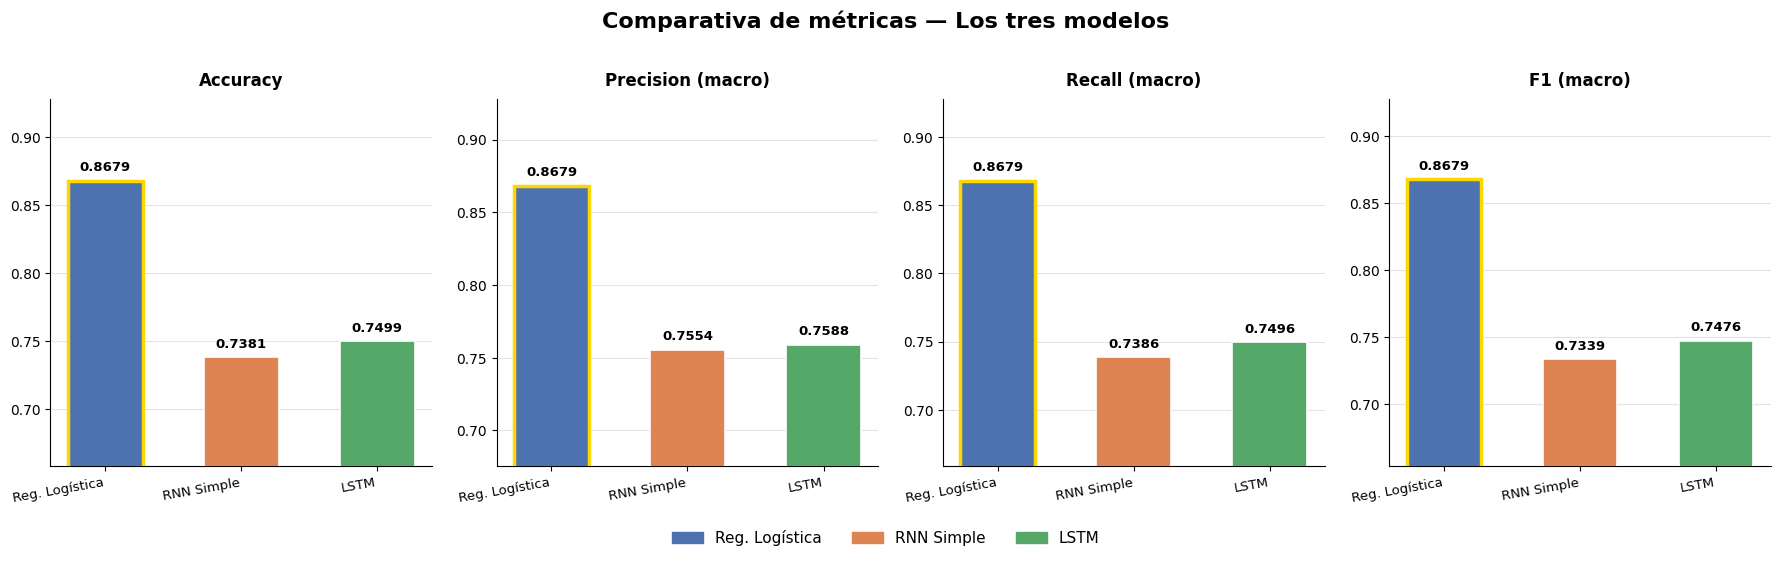


EVALUACIÓN - REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

    Negativo       0.87      0.87      0.87      4940
    Positivo       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917

EVALUACIÓN - MODELO RNN
              precision    recall  f1-score   support

    Negativo       0.69      0.87      0.77      4940
    Positivo       0.82      0.61      0.70      4977

    accuracy                           0.74      9917
   macro avg       0.76      0.74      0.73      9917
weighted avg       0.76      0.74      0.73      9917

EVALUACIÓN - MODELO LSTM
              precision    recall  f1-score   support

    Negativo       0.81      0.66      0.72      4940
    Positivo       0.71      0.84      0.77      4977

    accuracy                           0.75      9917
   macro avg       0.76      0.75      0.75  

In [ ]:
# ── Predicciones de RNN y LSTM ──────────────────────────────────────────────
y_pred_rnn_prob  = rnn_model.predict(X_test,  verbose=0).flatten()
y_pred_lstm_prob = lstm_model.predict(X_test, verbose=0).flatten()

y_pred_rnn  = (y_pred_rnn_prob  >= 0.5).astype(int)
y_pred_lstm = (y_pred_lstm_prob >= 0.5).astype(int)

# ── Métricas individuales ────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

acc_rnn  = accuracy_score(y_test, y_pred_rnn)
acc_lstm = accuracy_score(y_test, y_pred_lstm)

modelos   = ['Reg. Logística', 'RNN Simple', 'LSTM']
accs      = [acc_lr,   acc_rnn,   acc_lstm]
precs     = [prec_lr,  precision_score(y_test, y_pred_rnn, average='macro'),
                       precision_score(y_test, y_pred_lstm, average='macro')]
recs      = [rec_lr,   recall_score(y_test, y_pred_rnn, average='macro'),
                       recall_score(y_test, y_pred_lstm, average='macro')]
f1s       = [f1_lr,    f1_score(y_test, y_pred_rnn, average='macro'),
                       f1_score(y_test, y_pred_lstm, average='macro')]

# ── Paleta y estilo ──────────────────────────────────────────────────────────
COLORES   = ['#4C72B0', '#DD8452', '#55A868']   # azul / naranja / verde
METRICAS  = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
VALORES   = [accs, precs, recs, f1s]

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False})

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparativa de métricas — Los tres modelos', fontsize=16,
             fontweight='bold', y=1.02)

x = np.arange(len(modelos))

for ax, metrica, vals in zip(axes, METRICAS, VALORES):
    bars = ax.bar(x, vals, color=COLORES, width=0.55, edgecolor='white',
                  linewidth=1.2, zorder=3)
    # Etiqueta de valor encima de cada barra
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_title(metrica, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=9.5, rotation=10, ha='right')
    ax.set_ylim(min(vals) - 0.08, min(max(vals) + 0.06, 1.0))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.grid(axis='y', alpha=0.35, zorder=0)
    # Resaltar la barra ganadora
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('#FFD700')
    bars[best_idx].set_linewidth(2.5)

# Leyenda compartida
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=m) for c, m in zip(COLORES, modelos)]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('comparativa_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Reportes textuales ───────────────────────────────────────────────────────
print('\n' + '='*55)
print('EVALUACIÓN - REGRESIÓN LOGÍSTICA')
print('='*55)
print(classification_report(y_test_lr, y_pred_lr, target_names=['Negativo','Positivo']))

print('='*55)
print('EVALUACIÓN - MODELO RNN')
print('='*55)
print(classification_report(y_test, y_pred_rnn, target_names=['Negativo','Positivo']))

print('='*55)
print('EVALUACIÓN - MODELO LSTM')
print('='*55)
print(classification_report(y_test, y_pred_lstm, target_names=['Negativo','Positivo']))


## 14. Curvas de entrenamiento — RNN vs LSTM

Las curvas de entrenamiento revelan comportamientos muy distintos entre ambas arquitecturas. La Regresión Logística no aparece aquí porque al no entrenarse por épocas no tiene este tipo de historial.

En la RNN se ve claramente la inestabilidad que ya se anticipaba: la accuracy de validación tiene un pico aislado en la época 3 que llega cerca del 0.75 para luego caer bruscamente y estabilizarse alrededor del 0.51, prácticamente al nivel del azar. La curva de train tampoco muestra una tendencia de mejora sostenida, oscilando entre 0.51 y 0.56 durante todo el entrenamiento. Este comportamiento errático en la validación, con ese pico y caída tan pronunciados, sugiere que la RNN no está capturando patrones generalizables sino que en algún momento encontró una configuración de pesos favorable que no pudo mantener.

La LSTM muestra un panorama diferente. Tanto la accuracy de entrenamiento como la de validación suben de forma más coherente durante las primeras épocas, alcanzando su mejor punto alrededor de la época 4 con una val_accuracy cercana al 0.75. A partir de ahí ambas curvas empiezan a descender, lo que llevó al EarlyStopping a detener el entrenamiento en la época 7. La loss de validación también refleja esto: baja hasta la época 4 y luego sube progresivamente, señal de que el modelo empezó a sobreajustarse. Aunque la LSTM tampoco logra una convergencia estable, su curva es claramente más ordenada que la de la RNN y evidencia que sí aprendió algo útil antes de empezar a degradarse.

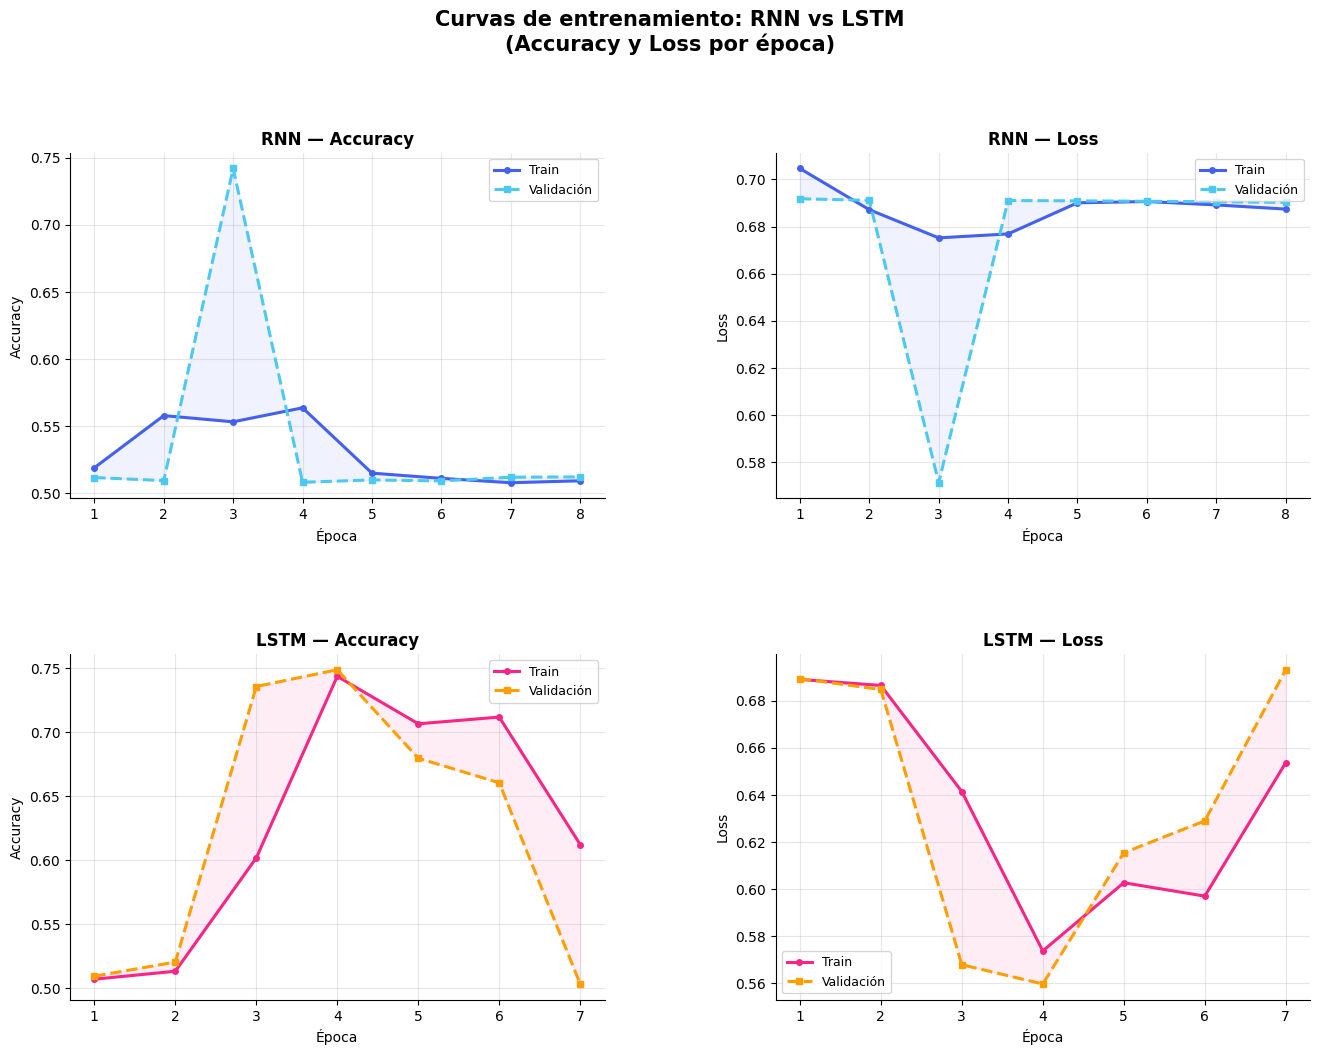

Gráfica guardada como curvas_entrenamiento.png


In [ ]:
# Paleta y configuración
C_RNN_TRAIN  = '#4361EE'
C_RNN_VAL    = '#4CC9F0'
C_LSTM_TRAIN = '#F72585'
C_LSTM_VAL   = '#FF9E00'

fig = plt.figure(figsize=(16, 11))
fig.suptitle('Curvas de entrenamiento: RNN vs LSTM\n(Accuracy y Loss por época)',
             fontsize=15, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.32)

epochs_rnn  = range(1, len(history_rnn.history['accuracy'])  + 1)
epochs_lstm = range(1, len(history_lstm.history['accuracy']) + 1)

# ── RNN Accuracy ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_rnn, history_rnn.history['accuracy'],
         color=C_RNN_TRAIN, lw=2.2, label='Train', marker='o', markersize=4)
ax1.plot(epochs_rnn, history_rnn.history['val_accuracy'],
         color=C_RNN_VAL, lw=2.2, linestyle='--', label='Validación', marker='s', markersize=4)
ax1.fill_between(epochs_rnn,
                 history_rnn.history['accuracy'],
                 history_rnn.history['val_accuracy'],
                 alpha=0.08, color=C_RNN_TRAIN)
ax1.set_title('RNN — Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# ── RNN Loss ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_rnn, history_rnn.history['loss'],
         color=C_RNN_TRAIN, lw=2.2, label='Train', marker='o', markersize=4)
ax2.plot(epochs_rnn, history_rnn.history['val_loss'],
         color=C_RNN_VAL, lw=2.2, linestyle='--', label='Validación', marker='s', markersize=4)
ax2.fill_between(epochs_rnn,
                 history_rnn.history['loss'],
                 history_rnn.history['val_loss'],
                 alpha=0.08, color=C_RNN_TRAIN)
ax2.set_title('RNN — Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Loss')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# ── LSTM Accuracy ─────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(epochs_lstm, history_lstm.history['accuracy'],
         color=C_LSTM_TRAIN, lw=2.2, label='Train', marker='o', markersize=4)
ax3.plot(epochs_lstm, history_lstm.history['val_accuracy'],
         color=C_LSTM_VAL, lw=2.2, linestyle='--', label='Validación', marker='s', markersize=4)
ax3.fill_between(epochs_lstm,
                 history_lstm.history['accuracy'],
                 history_lstm.history['val_accuracy'],
                 alpha=0.08, color=C_LSTM_TRAIN)
ax3.set_title('LSTM — Accuracy', fontsize=12, fontweight='bold')
ax3.set_xlabel('Época'); ax3.set_ylabel('Accuracy')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# ── LSTM Loss ─────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs_lstm, history_lstm.history['loss'],
         color=C_LSTM_TRAIN, lw=2.2, label='Train', marker='o', markersize=4)
ax4.plot(epochs_lstm, history_lstm.history['val_loss'],
         color=C_LSTM_VAL, lw=2.2, linestyle='--', label='Validación', marker='s', markersize=4)
ax4.fill_between(epochs_lstm,
                 history_lstm.history['loss'],
                 history_lstm.history['val_loss'],
                 alpha=0.08, color=C_LSTM_TRAIN)
ax4.set_title('LSTM — Loss', fontsize=12, fontweight='bold')
ax4.set_xlabel('Época'); ax4.set_ylabel('Loss')
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
ax4.spines[['top','right']].set_visible(False)

plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada como curvas_entrenamiento.png')


## 15. Matrices de confusión — Los tres modelos

Al analizar las matrices de confusión se comprende mejor el comportamiento real de cada modelo.

La Regresión Logística presenta el comportamiento más equilibrado. Clasifica correctamente el 86.5% de las reseñas negativas y el 87.1% de las positivas, con una cantidad de errores muy similar en ambas direcciones (666 falsos positivos y 644 falsos negativos). Es el único modelo que no evidencia un sesgo marcado hacia alguna de las clases.

En contraste, la RNN muestra el patrón más problemático. Aunque su capacidad para identificar reseñas negativas es alta (86.8%), prácticamente igual a la de la Regresión Logística, su desempeño en la clase positiva cae de forma considerable. Solo el 60.9% de las reseñas positivas se clasifican correctamente, mientras que el 39.1% se confunden como negativas. Esto refuerza lo observado en el reporte de clasificación: la RNN aprende razonablemente bien el sentimiento negativo, pero tiene dificultades importantes para capturar el positivo, posiblemente porque las expresiones positivas en reseñas de cine suelen ser más elaboradas y dependen en mayor medida del contexto general del texto.

Por su parte, la LSTM exhibe el comportamiento inverso. Logra identificar correctamente el 84.3% de las reseñas positivas, pero solo el 65.6% de las negativas, lo que se traduce en 1.698 reseñas negativas clasificadas erróneamente como positivas. Este contraste entre modelos es en sí mismo un hallazgo relevante, ya que evidencia cómo cada arquitectura procesa de manera distinta la información secuencial.

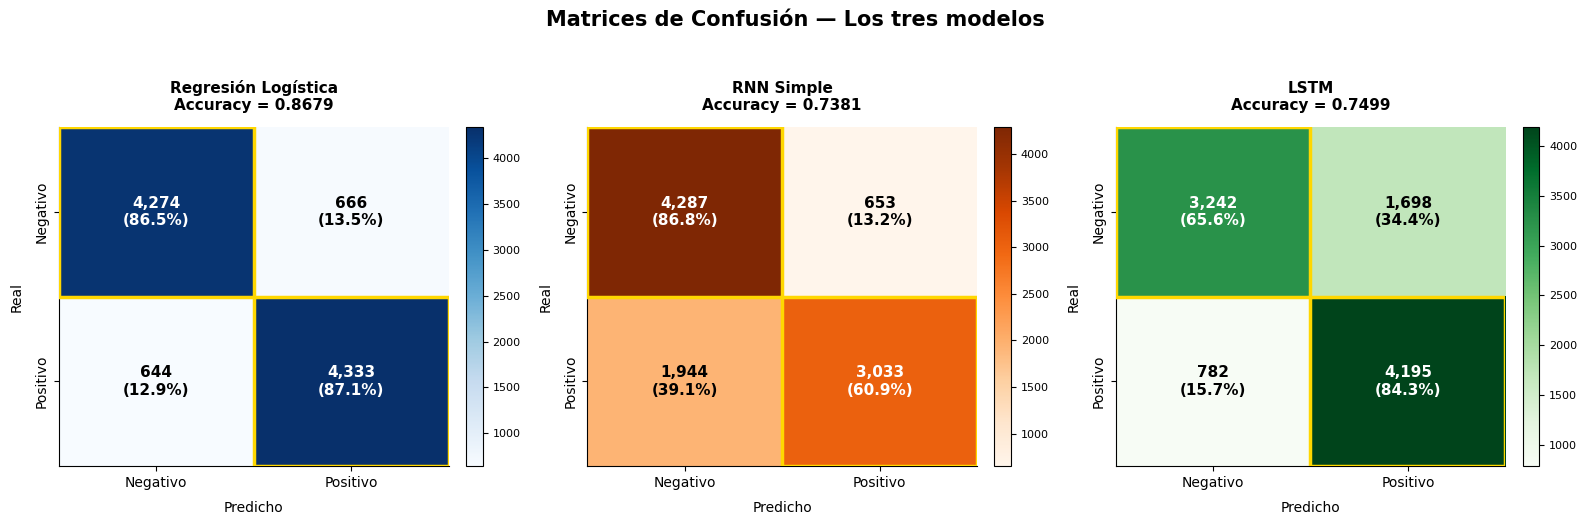

Gráfica guardada como matrices_confusion.png


In [ ]:
CMAPS   = ['Blues', 'Oranges', 'Greens']
TITLES  = ['Regresión Logística', 'RNN Simple', 'LSTM']
PREDS   = [y_pred_lr, y_pred_rnn, y_pred_lstm]
TRUES   = [y_test_lr, y_test,     y_test]
ACCVALS = [acc_lr,    acc_rnn,    acc_lstm]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrices de Confusión — Los tres modelos', fontsize=15,
             fontweight='bold', y=1.04)

LABELS = ['Negativo', 'Positivo']

for ax, cmap, title, y_pred_m, y_true_m, acc in zip(
        axes, CMAPS, TITLES, PREDS, TRUES, ACCVALS):

    cm = confusion_matrix(y_true_m, y_pred_m)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')

    # Título con accuracy
    ax.set_title(f'{title}\nAccuracy = {acc:.4f}', fontsize=11,
                 fontweight='bold', pad=12)

    # Etiquetas de ejes
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_yticklabels(LABELS, fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Predicho', fontsize=10, labelpad=8)
    ax.set_ylabel('Real', fontsize=10, labelpad=8)

    # Anotaciones: valor absoluto + porcentaje
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i,
                    f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

    # Borde de la diagonal en dorado para indicar aciertos
    for k in range(2):
        rect = plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                              fill=False, edgecolor='#FFD700',
                              lw=2.5, zorder=5)
        ax.add_patch(rect)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada como matrices_confusion.png')


## 16. Tabla comparativa de resultados

La tabla consolida los resultados de los tres modelos en un solo lugar. La Regresión Logística con promedio de Word2Vec fue claramente superior, con 0.8679 en todas las métricas, superando a la RNN y la LSTM que se mueven entre 0.74 y 0.75. La LSTM mejora ligeramente a la RNN en la mayoría de métricas, pero la diferencia entre ambas es pequeña comparada con la brecha que las separa del modelo más simple, lo que sugiere que para este dataset el promedio de embeddings captura suficientemente bien el sentimiento sin necesidad de modelar la secuencia completa.


In [ ]:
# --- Tabla comparativa de resultados de los tres modelos ---

resultados = {
    'Modelo': [
        'Regresión Logística\n(promedio Word2Vec)',
        'RNN Simple\n(secuencia Word2Vec)',
        'LSTM\n(secuencia Word2Vec)'
    ],
    'Accuracy': [
        acc_lr,
        acc_rnn,
        acc_lstm
    ],
    'F1 (macro)': [
        f1_lr,
        f1_score(y_test, y_pred_rnn,  average='macro'),
        f1_score(y_test, y_pred_lstm, average='macro')
    ],
    'Precision (macro)': [
        prec_lr,
        precision_score(y_test, y_pred_rnn,  average='macro'),
        precision_score(y_test, y_pred_lstm, average='macro')
    ],
    'Recall (macro)': [
        rec_lr,
        recall_score(y_test, y_pred_rnn,  average='macro'),
        recall_score(y_test, y_pred_lstm, average='macro')
    ]
}

df_res = pd.DataFrame(resultados)
df_res = df_res.set_index('Modelo')

# Formatear a 4 decimales y resaltar el mejor valor por columna
df_styled = df_res.style.format('{:.4f}').highlight_max(axis=0, color='#00000')
print("TABLA COMPARATIVA DE RESULTADOS")
print("(Verde: mejor valor en cada métrica)\n")
display(df_styled)


TABLA COMPARATIVA DE RESULTADOS
(Verde: mejor valor en cada métrica)



,Accuracy,F1 (macro),Precision (macro),Recall (macro)
Modelo,,,,
Regresión Logística (promedio Word2Vec),0.8679,0.8679,0.8679,0.8679
RNN Simple (secuencia Word2Vec),0.7381,0.7339,0.7554,0.7386
LSTM (secuencia Word2Vec),0.7499,0.7476,0.7588,0.7496


## 17. Prueba con nuevas reseñas


Se prueba cada modelo con siete reseñas nuevas para observar su comportamiento en ejemplos concretos. La Regresión Logística es la más consistente y segura en sus predicciones, alcanzando niveles de confianza del 99-100% en la mayoría de casos y clasificando correctamente todas las reseñas. La RNN y la LSTM en cambio muestran confianzas mucho más bajas, entre el 15% y el 77%, y cometen un error importante: clasifican como negativa la reseña "This movie was absolutely amazing, the acting was superb and the plot kept me engaged throughout", que es claramente positiva.

Además se puede observar que la RNN y la LSTM repiten los mismos porcentajes de confianza en varias reseñas distintas, lo que sugiere que ambos modelos no están discriminando bien entre ejemplos y están respondiendo de manera casi uniforme independientemente del contenido, algo que refuerza lo observado en las métricas globales.


In [ ]:
nuevas_resenas = [
    "An inspiring and beautifully crafted movie with memorable characters and a satisfying ending.",
    "I had high expectations, but the script was weak and the pacing ruined the experience.",
    "Brilliant cinematography and strong acting made this one of the best films I have seen this year.",
    "The dialogue was dull, the plot was messy, and I would not recommend it to anyone.",
    "This movie was absolutely amazing, the acting was superb and the plot kept me engaged throughout.",
    "Terrible film, complete waste of time. The story made no sense and the acting was awful.",
    "A decent movie, nothing extraordinary but enjoyable for a quiet evening."
]

print(f"{'Reseña':<65} {'Log. Reg.':>12} {'RNN':>18} {'LSTM':>18}")
print("-" * 115)

for resena in nuevas_resenas:
    tokens = tokenize(clean_text(resena))

    # Regresión Logística (vector promedio)
    vec_avg = review_to_vector(tokens, w2v_model).reshape(1, -1)
    prob_lr_new = clf.predict_proba(vec_avg)[0][1]
    label_lr_new = 'POSITIVO' if prob_lr_new >= 0.5 else 'NEGATIVO'

    # RNN y LSTM (secuencia padded)
    seq = tokens_to_sequence(tokens, word_to_idx)
    seq_padded = pad_sequences([seq], maxlen=MAX_LEN, padding='post', truncating='pre')
    prob_rnn_new  = rnn_model.predict(seq_padded,  verbose=0)[0][0]
    prob_lstm_new = lstm_model.predict(seq_padded, verbose=0)[0][0]
    label_rnn_new  = 'POSITIVO' if prob_rnn_new  >= 0.5 else 'NEGATIVO'
    label_lstm_new = 'POSITIVO' if prob_lstm_new >= 0.5 else 'NEGATIVO'

    print(f"{resena[:64]:<65} "
          f"{label_lr_new+f' ({prob_lr_new:.0%})':>12} "
          f"{label_rnn_new+f' ({prob_rnn_new:.0%})':>18} "
          f"{label_lstm_new+f' ({prob_lstm_new:.0%})':>18}")
    print()


Reseña                                                               Log. Reg.                RNN               LSTM
-------------------------------------------------------------------------------------------------------------------
An inspiring and beautifully crafted movie with memorable charac  POSITIVO (100%)     POSITIVO (77%)     POSITIVO (71%)

I had high expectations, but the script was weak and the pacing   NEGATIVO (0%)     NEGATIVO (24%)     NEGATIVO (15%)

Brilliant cinematography and strong acting made this one of the   POSITIVO (99%)     POSITIVO (77%)     POSITIVO (71%)

The dialogue was dull, the plot was messy, and I would not recom  NEGATIVO (0%)     NEGATIVO (24%)     NEGATIVO (15%)

This movie was absolutely amazing, the acting was superb and the  POSITIVO (70%)     NEGATIVO (24%)     NEGATIVO (15%)

Terrible film, complete waste of time. The story made no sense a  NEGATIVO (0%)     NEGATIVO (24%)     NEGATIVO (15%)

A decent movie, nothing extraordinary but enjoyab

## 18. Análisis comparativo

---

### ¿Qué diferencias observaron entre la RNN y la LSTM?

La diferencia más evidente estuvo en la estabilidad durante el entrenamiento. La RNN presentó curvas de accuracy y pérdida irregulares, con saltos bruscos entre épocas y sin una tendencia de mejora sostenida, mientras que la LSTM mostró una convergencia más ordenada, subiendo de forma progresiva hasta su mejor punto antes de empezar a degradarse. Esto tiene una explicación directa en la arquitectura: la LSTM incorpora compuertas internas que le permiten decidir qué información conservar y qué descartar a lo largo de la secuencia, algo de lo que la RNN simple carece completamente.

En cuanto al rendimiento final, la LSTM superó a la RNN con un accuracy de 0.7499 frente a 0.7381, una diferencia modesta pero consistente. Donde la diferencia se hace más notoria es en el comportamiento por clase: la RNN mostró un sesgo claro hacia predecir negativos, clasificando mal el 39.1% de las reseñas positivas, mientras que la LSTM distribuyó mejor sus errores aunque con el patrón opuesto. En las pruebas con reseñas nuevas también se observó que ambos modelos tendían a repetir los mismos porcentajes de confianza independientemente del contenido, lo que sugiere que ninguno logró discriminar con suficiente precisión entre ejemplos.

---

### ¿Qué diferencias encuentran respecto al modelo anterior?

La Regresión Logística con promedio Word2Vec alcanzó un accuracy de 0.8679, superando ampliamente a las dos arquitecturas recurrentes. La diferencia conceptual entre los enfoques es clara: mientras que la Regresión Logística comprime toda la reseña en un único vector promedio y clasifica a partir de él, la RNN y la LSTM procesan la secuencia completa de tokens en orden, lo que teóricamente les permite capturar el orden de las palabras y construcciones como negaciones del tipo not good o wasn't bad.
Sin embargo, en la práctica esa ventaja estructural no se tradujo en mejores resultados. Una posible explicación es que el promedio de embeddings Word2Vec ya captura suficiente información semántica para clasificación binaria de sentimiento, donde la polaridad general del texto suele ser más determinante que el orden exacto de las palabras. Las arquitecturas recurrentes tienden a brillar más en tareas donde el orden importa de manera crítica, como generación de texto o análisis de discurso complejo. A esto se suma que la Regresión Logística es instantánea en entrenamiento y no requiere ninguna preparación adicional de los datos, mientras que las redes recurrentes demandaron indexación, padding, construcción de la matriz de embeddings y varios minutos de entrenamiento, una complejidad que en este caso no se vio recompensada en las métricas.

---

### ¿Cómo cambian los resultados, las métricas y el comportamiento del entrenamiento?

La Regresión Logística produce un resultado fijo, determinista y perfectamente equilibrado entre clases, con un F1-score de 0.87 tanto para positivos como para negativos. La RNN y la LSTM en cambio muestran desequilibrios por clase, con la RNN fallando más en positivos y la LSTM más en negativos, y sus curvas de entrenamiento evidencian que ninguna logró una convergencia estable.

La RNN se detuvo en la época 8 sin haber aprendido una tendencia clara, y la LSTM alcanzó su mejor punto en la época 4 para luego degradarse progresivamente hasta que el EarlyStopping intervino en la época 7. En términos de estabilidad y consistencia, la Regresión Logística fue superior en todos los aspectos.

---

### ¿Qué ventajas y desventajas identifican en cada arquitectura?


* La Regresión Logística con promedio Word2Vec es extremadamente rápida, interpretable y no requiere GPU ni preparación elaborada de los datos. Su limitación es que pierde el orden de las palabras y no puede modelar dependencias secuenciales ni negaciones complejas.

* La RNN simple preserva el orden de los tokens y es relativamente liviana en parámetros, pero sufre del problema del desvanecimiento del gradiente en secuencias largas, lo que la hace poco confiable cuando el sentimiento depende de contexto lejano. Su entrenamiento fue el más inestable de los tres.

* La LSTM resuelve ese problema mediante sus compuertas internas, logrando un entrenamiento más estable y mejor manejo de dependencias a largo plazo. El costo es un mayor número de parámetros, más tiempo de cómputo y mayor riesgo de sobreajuste si no se regulariza adecuadamente.

---

### ¿Qué decisiones tomaron durante el diseño del modelo y por qué?

La primera decisión fue congelar la capa Embedding con trainable=False en ambos modelos, para que los pesos Word2Vec no se modificaran durante el entrenamiento y la comparación entre arquitecturas fuera justa, aislando el efecto del clasificador y no del embedding.

Para la longitud máxima de secuencia se usó el percentil 95, que resultó en 584 tokens. Usar el máximo absoluto de 2.439 hubiera implicado padding excesivo en la gran mayoría de reseñas, desperdiciando memoria y confundiendo a la red. El padding se aplicó al final y el truncado al inicio, conservando los tokens más recientes de cada reseña.

Se eligieron 64 unidades en la capa recurrente y un Dropout de 0.3 en ambos modelos. Aunque la arquitectura base es la misma, los hiperparámetros de entrenamiento difieren entre los dos: la RNN se entrenó con un learning rate de 5e-4, 20 épocas y una paciencia de 5, mientras que la LSTM usó un learning rate de 1e-3, 10 épocas y una paciencia de 3. Intentamos mantener exactamente la misma configuración para ambos, pero al hacerlo la LSTM no mejoraba o incluso bajaba su rendimiento. La LSTM, al ser más robusta por sus compuertas internas, respondió mejor a un learning rate más agresivo y a un esquema de entrenamiento más corto, siendo esa la configuración que nos dio los mejores resultados en cada caso.

Finalmente, mantener la misma arquitectura base para RNN y LSTM cambiando únicamente la capa recurrente fue una decisión deliberada para poder atribuir cualquier diferencia en los resultados exclusivamente al tipo de celda utilizada.